In [13]:
import sys
!{sys.executable} -m pip install scikit-learn

  Using cached joblib-1.5.3-py3-none-any.whl.metadata (5.5 kB)
  Using cached threadpoolctl-3.6.0-py3-none-any.whl.metadata (13 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.3/9.3 MB 10.1 MB/s eta 0:00:00a 0:00:01
Using cached joblib-1.5.3-py3-none-any.whl (309 kB)
Using cached threadpoolctl-3.6.0-py3-none-any.whl (18 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3/3 [scikit-learn] [scikit-learn]

[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: /usr/local/opt/python@3.10/bin/python3.10 -m pip install --upgrade pip


In [15]:
import sys
!{sys.executable} -m pip install streamlit


  Using cached streamlit-1.55.0-py3-none-any.whl.metadata (9.8 kB)
  Using cached altair-6.0.0-py3-none-any.whl.metadata (11 kB)
  Using cached blinker-1.9.0-py3-none-any.whl.metadata (1.6 kB)
  Using cached cachetools-7.0.5-py3-none-any.whl.metadata (5.6 kB)
  Using cached click-8.3.1-py3-none-any.whl.metadata (2.6 kB)
  Using cached gitpython-3.1.46-py3-none-any.whl.metadata (13 kB)
  Using cached pydeck-0.9.1-py2.py3-none-any.whl.metadata (4.1 kB)
  Using cached protobuf-6.33.5-cp39-abi3-macosx_10_9_universal2.whl.metadata (593 bytes)
  Using cached requests-2.32.5-py3-none-any.whl.metadata (4.9 kB)
  Using cached tenacity-9.1.4-py3-none-any.whl.metadata (1.2 kB)
  Using cached toml-0.10.2-py2.py3-none-any.whl.metadata (7.1 kB)
  Using cached jinja2-3.1.6-py3-none-any.whl.metadata (2.9 kB)
  Using cached jsonschema-4.26.0-py3-none-any.whl.metadata (7.6 kB)
  Using cached narwhals-2.18.0-py3-none-any.whl.metadata (14 kB)
  Using cached gitdb-4.0.12-py3-none-any.whl.metadata (1.2 kB)


In [17]:
import sys
!{sys.executable} -m pip install holidays

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 17.0 MB/s eta 0:00:00

[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: /usr/local/opt/python@3.10/bin/python3.10 -m pip install --upgrade pip


In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn
import streamlit as st
import holidays

In [19]:
ventas_path = "../data/raw/entrenamiento/ventas.csv"
competencia_path = "../data/raw/entrenamiento/ventas.csv"

ventas_df = pd.read_csv(ventas_path)
competencia_df = pd.read_csv(competencia_path)

ventas_df.head()
competencia_df.head()

,fecha,producto_id,nombre,categoria,subcategoria,precio_base,es_estrella,unidades_vendidas,precio_venta,ingresos
0,2021-10-25,PROD_001,Nike Air Zoom Pegasus 40,Running,Zapatillas Running,115,True,6,118.36,710.16
1,2021-10-25,PROD_002,Adidas Ultraboost 23,Running,Zapatillas Running,135,True,10,136.82,1368.20
2,2021-10-25,PROD_003,Asics Gel Nimbus 25,Running,Zapatillas Running,85,False,2,84.93,169.86
3,2021-10-25,PROD_004,New Balance Fresh Foam X 1080v12,Running,Zapatillas Running,75,False,2,75.42,150.84
4,2021-10-25,PROD_005,Nike Dri-FIT Miler,Running,Ropa Running,35,False,2,35.87,71.74


In [24]:
ventas_df.dtypes

fecha                 object
producto_id           object
nombre                object
categoria             object
subcategoria          object
precio_base            int64
es_estrella             bool
unidades_vendidas      int64
precio_venta         float64
ingresos             float64
dtype: object

In [25]:
competencia_df.dtypes

fecha                 object
producto_id           object
nombre                object
categoria             object
subcategoria          object
precio_base            int64
es_estrella             bool
unidades_vendidas      int64
precio_venta         float64
ingresos             float64
dtype: object

In [26]:
#Duplicados
duplicados = ventas_df.duplicated().sum()
print(f"El número de filas duplicadas en ventas_df es: {duplicados}")

#Estadistica descriptiva
print(ventas_df.describe(include='all'))

#Resumen final
if ventas_df.isnull().sum().sum() ==0:
    print("No hay valores nulos en ventas_df.")
else:
    print("Hay valores nulos en ventas_df.")

if duplicados == 0:
    print("No hay filas duplicadas en ventas_df.")
else:
    print("Hay filas duplicadas en ventas_df.")

El número de filas duplicadas en ventas_df es: 0
             fecha producto_id                    nombre categoria  \
count         3552        3552                      3552      3552   
unique         148          24                        24         4   
top     2021-10-25    PROD_001  Nike Air Zoom Pegasus 40   Running   
freq            24         148                       148      1184   
mean           NaN         NaN                       NaN       NaN   
std            NaN         NaN                       NaN       NaN   
min            NaN         NaN                       NaN       NaN   
25%            NaN         NaN                       NaN       NaN   
50%            NaN         NaN                       NaN       NaN   
75%            NaN         NaN                       NaN       NaN   
max            NaN         NaN                       NaN       NaN   

              subcategoria  precio_base es_estrella  unidades_vendidas  \
count                 3552  3552.000

In [27]:
#COmpetencia
print(competencia_df.dtypes)

#Nulos
print(competencia_df.isnull().sum())    

#Duplicados
duplicados_comp = competencia_df.duplicated().sum()
print(f"El número de filas duplicadas en competencia_df es: {duplicados_comp}")

#Estadistica descriptiva
print(competencia_df.describe(include='all'))

#Resumen final
if competencia_df.isnull().sum().sum() ==0:
    print("No hay valores nulos en competencia_df.")    
else:   
    print("Hay valores nulos en competencia_df.")

if duplicados_comp == 0:
    print("No hay filas duplicadas en competencia_df.")     
else:   
    print("Hay filas duplicadas en competencia_df.")

fecha                 object
producto_id           object
nombre                object
categoria             object
subcategoria          object
precio_base            int64
es_estrella             bool
unidades_vendidas      int64
precio_venta         float64
ingresos             float64
dtype: object
fecha                0
producto_id          0
nombre               0
categoria            0
subcategoria         0
precio_base          0
es_estrella          0
unidades_vendidas    0
precio_venta         0
ingresos             0
dtype: int64
El número de filas duplicadas en competencia_df es: 0
             fecha producto_id                    nombre categoria  \
count         3552        3552                      3552      3552   
unique         148          24                        24         4   
top     2021-10-25    PROD_001  Nike Air Zoom Pegasus 40   Running   
freq            24         148                       148      1184   
mean           NaN         NaN                   

In [28]:
#COnvertimos la columna fecha a tipo datetime en ambos dataframes

ventas_df['fecha'] = pd.to_datetime(ventas_df['fecha'])
competencia_df['fecha'] = pd.to_datetime(competencia_df['fecha'])

In [29]:
ventas_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3552 entries, 0 to 3551
Data columns (total 10 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   fecha              3552 non-null   datetime64[ns]
 1   producto_id        3552 non-null   object        
 2   nombre             3552 non-null   object        
 3   categoria          3552 non-null   object        
 4   subcategoria       3552 non-null   object        
 5   precio_base        3552 non-null   int64         
 6   es_estrella        3552 non-null   bool          
 7   unidades_vendidas  3552 non-null   int64         
 8   precio_venta       3552 non-null   float64       
 9   ingresos           3552 non-null   float64       
dtypes: bool(1), datetime64[ns](1), float64(2), int64(2), object(4)
memory usage: 253.3+ KB


In [30]:
competencia_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3552 entries, 0 to 3551
Data columns (total 10 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   fecha              3552 non-null   datetime64[ns]
 1   producto_id        3552 non-null   object        
 2   nombre             3552 non-null   object        
 3   categoria          3552 non-null   object        
 4   subcategoria       3552 non-null   object        
 5   precio_base        3552 non-null   int64         
 6   es_estrella        3552 non-null   bool          
 7   unidades_vendidas  3552 non-null   int64         
 8   precio_venta       3552 non-null   float64       
 9   ingresos           3552 non-null   float64       
dtypes: bool(1), datetime64[ns](1), float64(2), int64(2), object(4)
memory usage: 253.3+ KB


In [39]:
#integramos los datos en un solo dataframe
df = pd.merge(
    ventas_df,
    competencia_df,
    how='inner',
    on=['fecha','producto_id','nombre','categoria','subcategoria','precio_base','es_estrella','unidades_vendidas','precio_venta','ingresos']
)

print(df.head())

       fecha producto_id                            nombre categoria  \
0 2021-10-25    PROD_001          Nike Air Zoom Pegasus 40   Running   
1 2021-10-25    PROD_002              Adidas Ultraboost 23   Running   
2 2021-10-25    PROD_003               Asics Gel Nimbus 25   Running   
3 2021-10-25    PROD_004  New Balance Fresh Foam X 1080v12   Running   
4 2021-10-25    PROD_005                Nike Dri-FIT Miler   Running   

         subcategoria  precio_base  es_estrella  unidades_vendidas  \
0  Zapatillas Running          115         True                  6   
1  Zapatillas Running          135         True                 10   
2  Zapatillas Running           85        False                  2   
3  Zapatillas Running           75        False                  2   
4        Ropa Running           35        False                  2   

   precio_venta  ingresos  
0        118.36    710.16  
1        136.82   1368.20  
2         84.93    169.86  
3         75.42    150.84  
4     

In [40]:
df.head()

,fecha,producto_id,nombre,categoria,subcategoria,precio_base,es_estrella,unidades_vendidas,precio_venta,ingresos
0,2021-10-25,PROD_001,Nike Air Zoom Pegasus 40,Running,Zapatillas Running,115,True,6,118.36,710.16
1,2021-10-25,PROD_002,Adidas Ultraboost 23,Running,Zapatillas Running,135,True,10,136.82,1368.20
2,2021-10-25,PROD_003,Asics Gel Nimbus 25,Running,Zapatillas Running,85,False,2,84.93,169.86
3,2021-10-25,PROD_004,New Balance Fresh Foam X 1080v12,Running,Zapatillas Running,75,False,2,75.42,150.84
4,2021-10-25,PROD_005,Nike Dri-FIT Miler,Running,Ropa Running,35,False,2,35.87,71.74


Analisis exploratorio

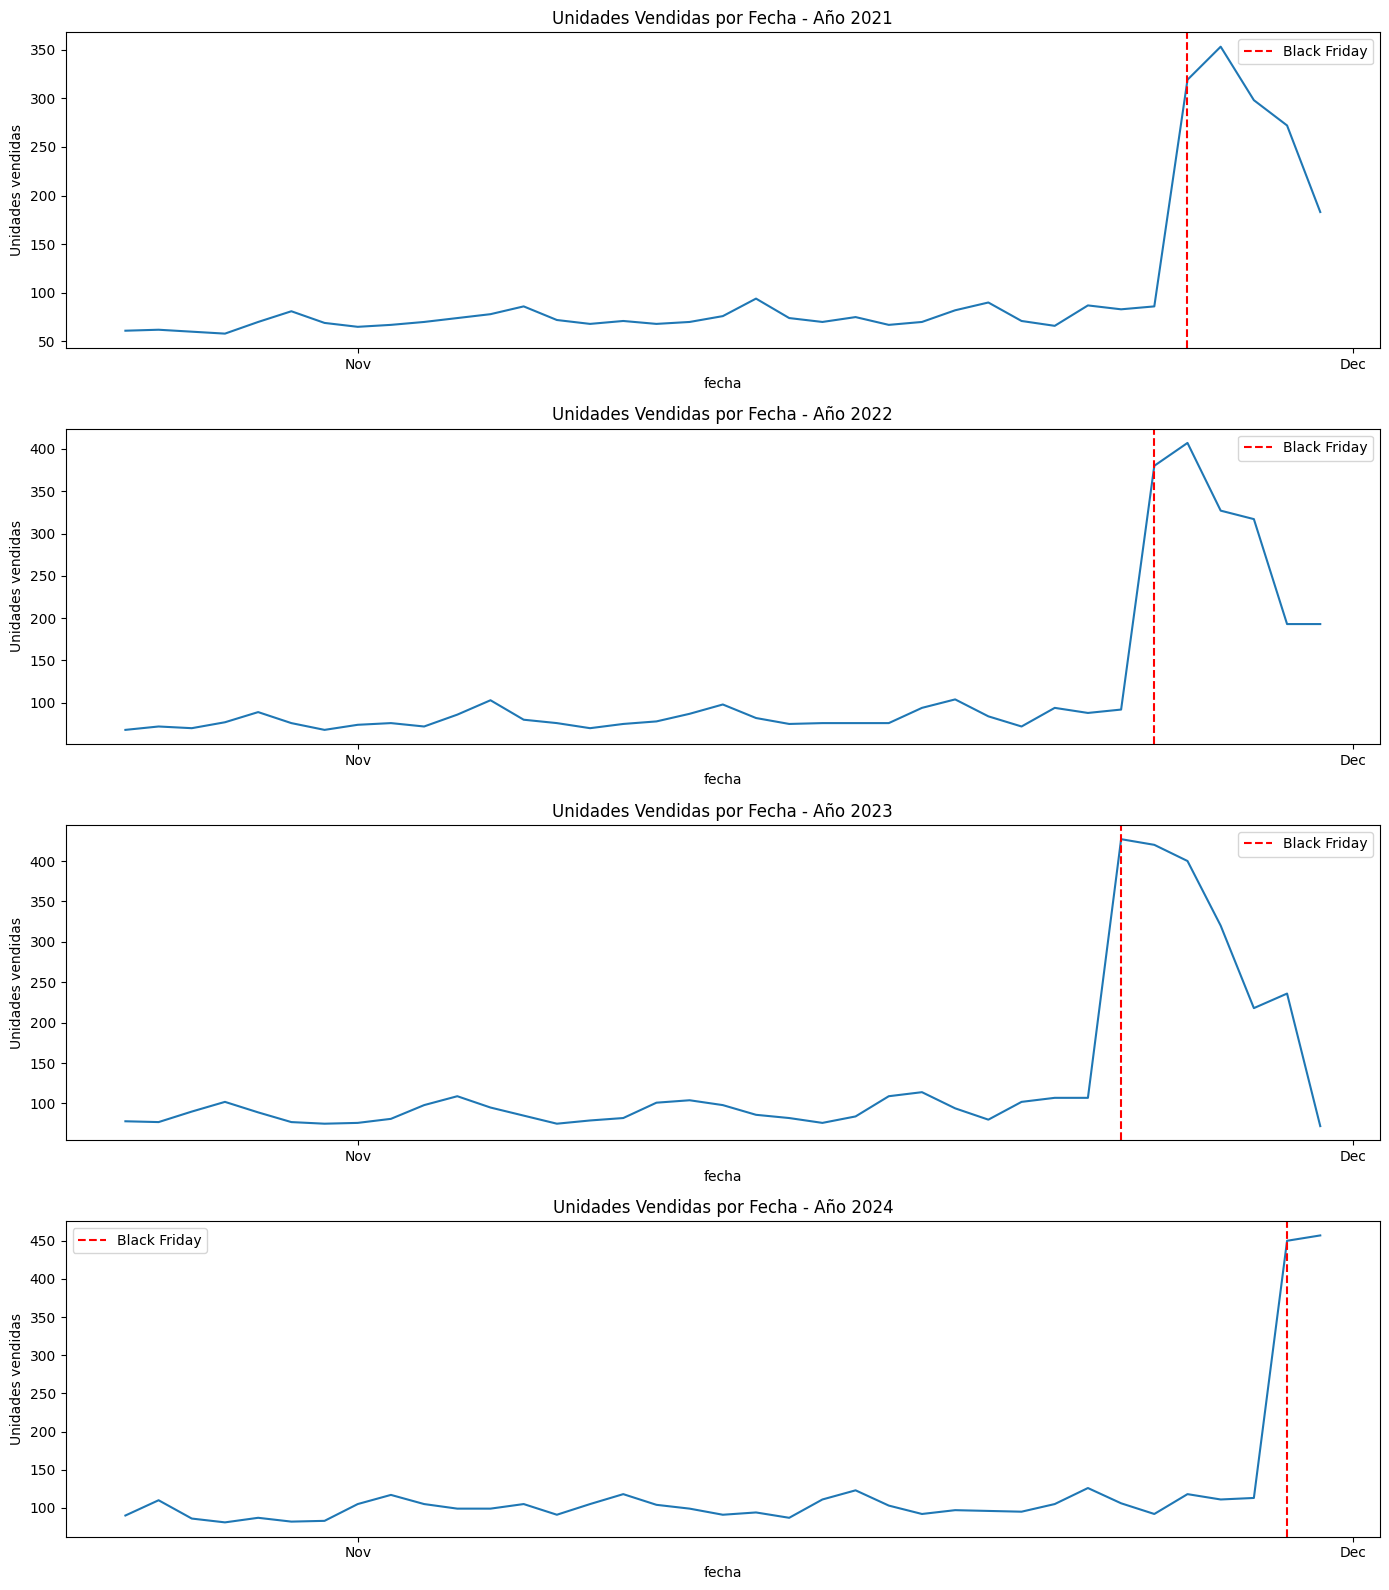

In [41]:
#Grafico de lineas temporales por anio con la suma de utilidades vendias por año y marcado Black Friday

import matplotlib.dates as mdates
from pandas.tseries.holiday import USFederalHolidayCalendar

#Extraemos dia y aòo de la semana
if 'año' not in df.columns:
    df['año'] = df['fecha'].dt.year
if 'mes' not in df.columns:
    df['mes'] = df['fecha'].dt.month
if 'dia_semana' not in df.columns:
    df['dia_semana'] = df['fecha'].dt.day_name()

#Îdentificamos Back Friday
def get_black_friday(years):
    bf_dates = []
    for y in years:
        nov = pd.date_range(start=f'{y}-11-01', end=f'{y}-11-30',freq='D')
        fridays = nov[nov.weekday == 4]
        bf_dates.append(fridays[-1])
    return bf_dates

black_fridays = get_black_friday(df['año'].unique())

fig,axes = plt.subplots(len(df['año'].unique()),1, figsize=(14,4*len(df['año'].unique())), sharex=False)
if len(df['año'].unique()) == 1:
    axes = [axes]
for i, year in enumerate(sorted(df['año'].unique())):
    df_year = df[df['año'] == year]
    df_group= df_year.groupby('fecha')['unidades_vendidas'].sum().reset_index()
    sns.lineplot(data=df_group, x='fecha', y='unidades_vendidas', ax=axes[i])
    axes[i].set_title(f'Unidades Vendidas por Fecha - Año {year}')
    axes[i].set_ylabel('Unidades vendidas')
    axes[i].xaxis.set_major_locator(mdates.MonthLocator())
    axes[i].xaxis.set_major_formatter(mdates.DateFormatter('%b'))
    #Marcamos el Black Friday   
    bf = [d for d in black_fridays if d.year == year]
    for bfd in bf:
        axes[i].axvline(bfd, color='red', linestyle='--', label='Black Friday')
    axes[i].legend()
plt.tight_layout()
plt.show()

/var/folders/r0/96mlrgd13m30sgcx6bnhr9yh0000gn/T/ipykernel_1510/530672406.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=df_dia.index, y=df_dia.values,palette='viridis')


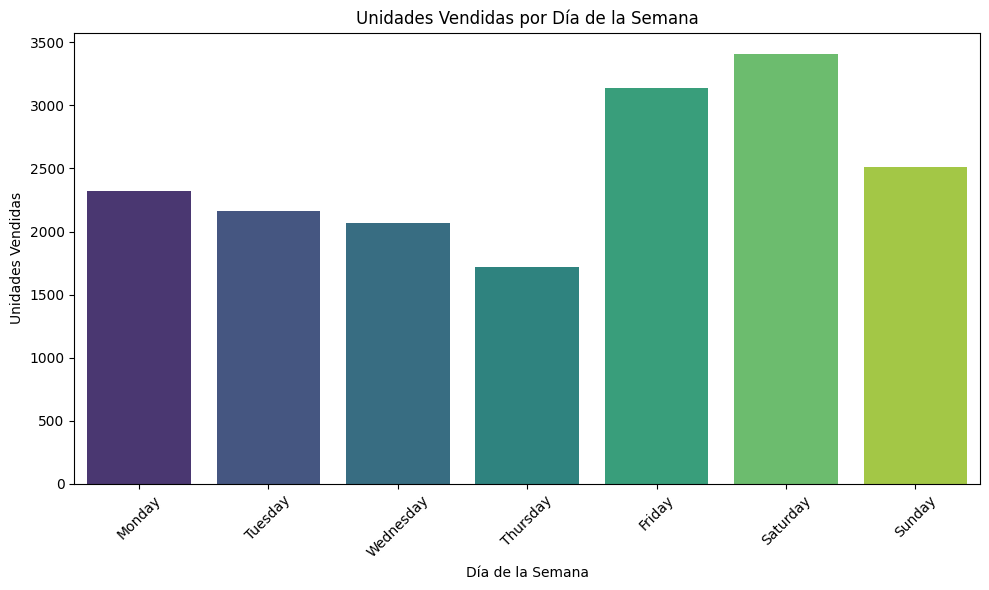

In [44]:
#Grafico de suma de unidades vendidas por dia a la semana
plt.figure(figsize=(10,6))
df_dia = df.groupby('dia_semana')['unidades_vendidas'].sum().reindex(['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday'])
sns.barplot(x=df_dia.index, y=df_dia.values,palette='viridis')
plt.title('Unidades Vendidas por Día de la Semana')
plt.xlabel('Día de la Semana')
plt.ylabel('Unidades Vendidas')
plt.xticks(rotation=45)
plt.tight_layout()  
plt.show()  

/var/folders/r0/96mlrgd13m30sgcx6bnhr9yh0000gn/T/ipykernel_1510/2553576082.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=df_cat.index, y=df_cat.values,palette='crest')


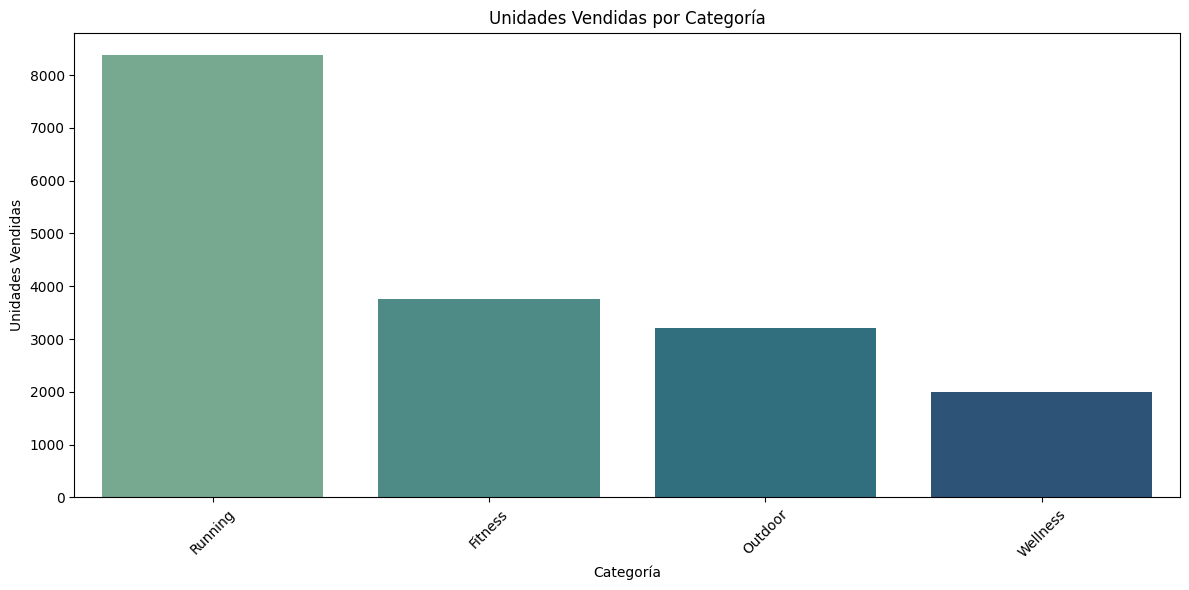

In [45]:
#Grafico de suma de unidades vendias por categoria
plt.figure(figsize=(12,6))
df_cat = df.groupby('categoria')['unidades_vendidas'].sum().sort_values(ascending=False)
sns.barplot(x=df_cat.index, y=df_cat.values,palette='crest')
plt.title('Unidades Vendidas por Categoría')
plt.xlabel('Categoría')
plt.ylabel('Unidades Vendidas')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

/var/folders/r0/96mlrgd13m30sgcx6bnhr9yh0000gn/T/ipykernel_1510/4215184003.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=df_subcat.index, y=df_subcat.values,palette='mako')


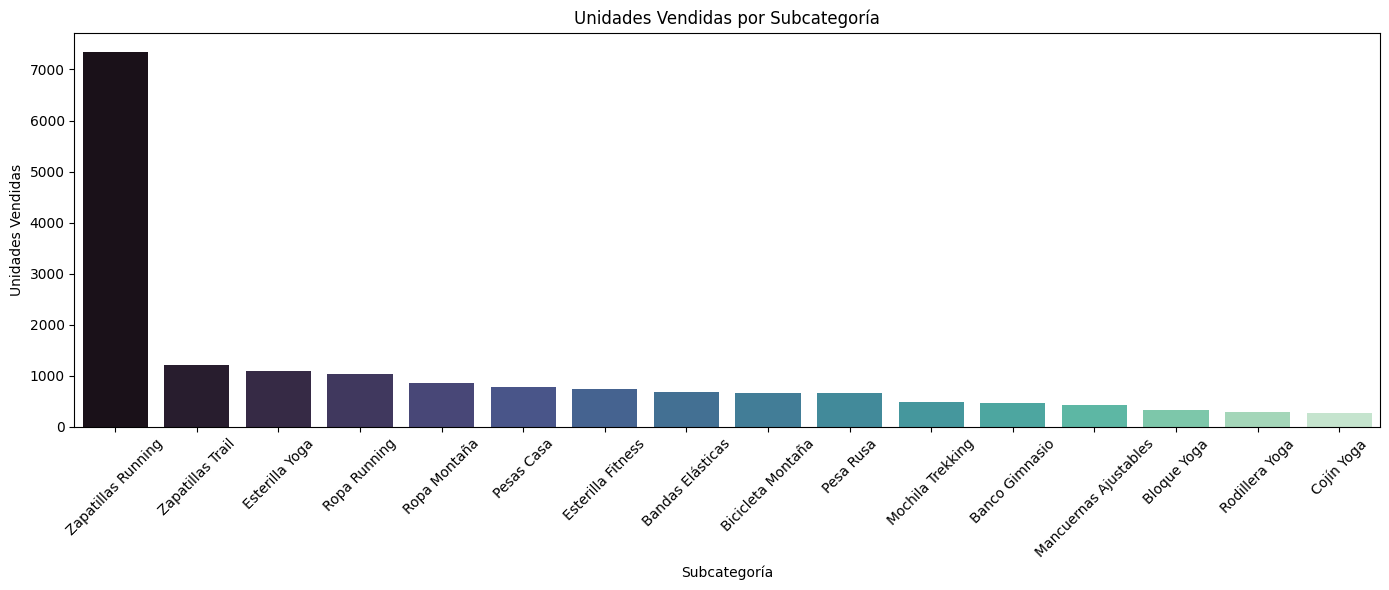

In [46]:
#grafico de suma de unidades vendidas por subcategoria
plt.figure(figsize=(14,6))
df_subcat = df.groupby('subcategoria')['unidades_vendidas'].sum().sort_values(ascending=False)
sns.barplot(x=df_subcat.index, y=df_subcat.values,palette='mako')
plt.title('Unidades Vendidas por Subcategoría')
plt.xlabel('Subcategoría')
plt.ylabel('Unidades Vendidas')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

/var/folders/r0/96mlrgd13m30sgcx6bnhr9yh0000gn/T/ipykernel_1510/313547304.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='nombre',y='unidades_vendidas', data=df_top, palette='rocket')


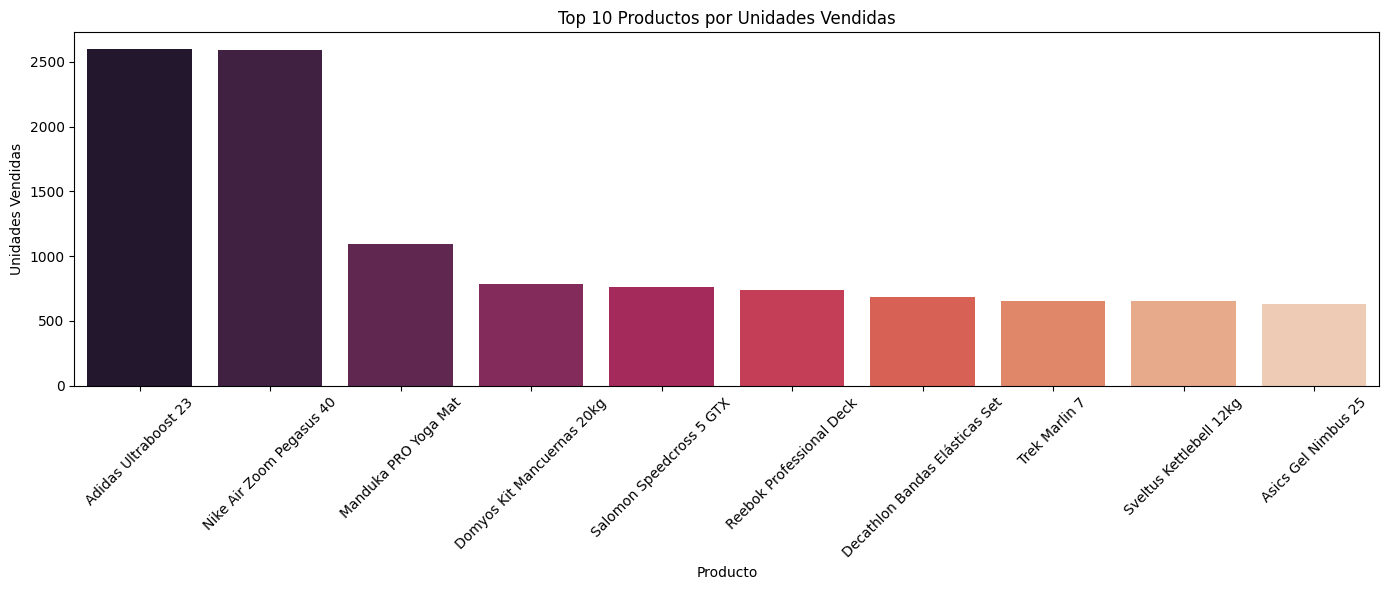

In [47]:
#Grafico de los top productos por unidades vendidas
plt.figure(figsize=(14,6))
top_n= 10
df_top= df.groupby(['producto_id','nombre'])['unidades_vendidas'].sum().sort_values(ascending=False).head(top_n).reset_index()
sns.barplot(x='nombre',y='unidades_vendidas', data=df_top, palette='rocket')
plt.title(f'Top {top_n} Productos por Unidades Vendidas')
plt.xlabel('Producto')
plt.ylabel('Unidades Vendidas')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

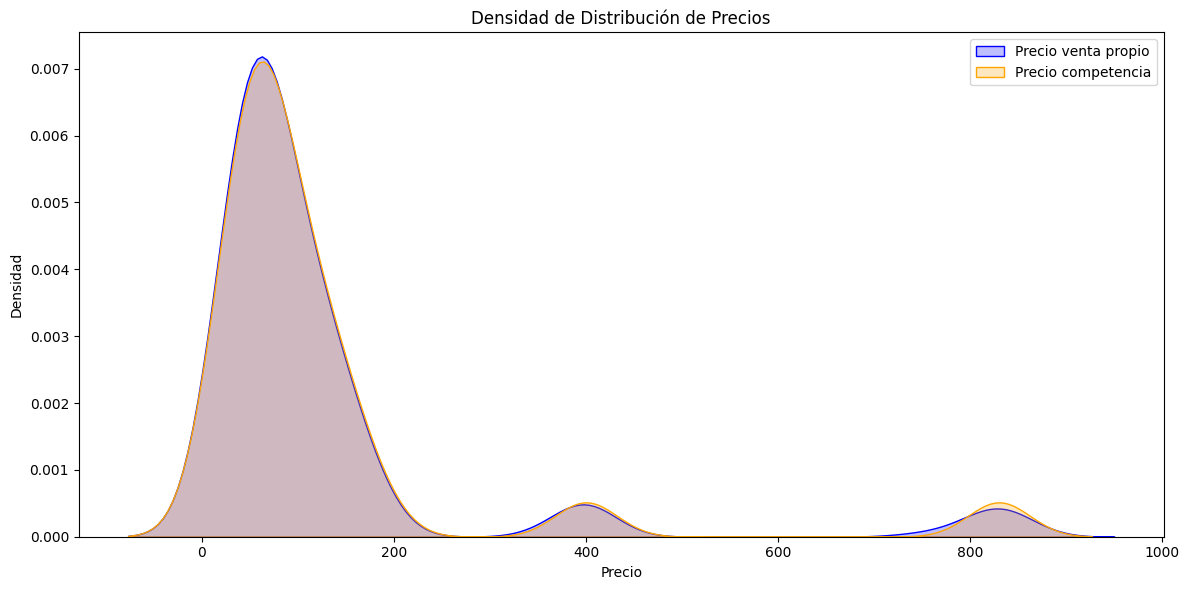

In [49]:
#analisis de la densidad de distribucion de los precios propios y de amazon
plt.figure(figsize=(12,6))
sns.kdeplot(df['precio_venta'],label='Precio venta propio',fill=True,color='blue')
sns.kdeplot(df['precio_base'],label='Precio competencia',fill=True,color='orange')
plt.title('Densidad de Distribución de Precios')
plt.xlabel('Precio')
plt.ylabel('Densidad')
plt.legend()
plt.tight_layout()
plt.show()

##Preparacion de datos


In [54]:
#creamos las variables temporales y de calendario usando holidays para España

df['año'] = df['fecha'].dt.year
df['mes'] = df['fecha'].dt.month
df['dia_mes']= df['fecha'].dt.day
df['dia_semana'] = df['fecha'].dt.day_name()
df['es_fin_semana']= df['dia_semana'].isin(['Saturday','Sunday'])

#Festivos España
festivos_es = holidays.CountryHoliday('ES', years=df['año'].unique())
df['es_festivo'] = df['fecha'].isin(festivos_es)

#Black Friday (ultimo viernes de noviembre)

def es_black_friday(fecha):
    if fecha.month == 11:
        nov = pd.date_range(start=f'{fecha.year}-11-01', end=f'{fecha.year}-11-30', freq='D')
        fridays = nov[nov.weekday == 4]
        return fecha in fridays[-1:]
    return False
df['es_black_friday'] = df['fecha'].apply(es_black_friday)

#Cyber monday (lunes siguiente al Black Friday)
def es_cyber_monday(fecha):
    if fecha.month == 11 or fecha.month == 12:
        nov = pd.date_range(start=f'{fecha.year}-11-01', end=f'{fecha.year}-11-30', freq='D')
        fridays = nov[nov.weekday == 4]
        black_friday = fridays[-1]
        cyber_monday = black_friday + pd.Timedelta(days=3)
        return fecha == cyber_monday
    return False
df['es_cyber_monday'] = df['fecha'].apply(es_cyber_monday)

#variable: trimestr

trimestre_map ={1:1,2:1,3:1,4:2,5:2,6:2,7:3,8:3,9:3,10:4,11:4,12:4}
df['trimestre'] = df['mes'].map(trimestre_map)

#variable semana del anio
df['semana_año'] = df['fecha'].dt.isocalendar().week

#variable: dia laborable (ni fin de semana ni festivo)
df['es_laborable'] = ~df['es_fin_semana'] & ~df['es_festivo']

#variable inicio /fin de mes
df['es_inicio_mes'] = df['fecha'].dt.day <= 3
df['es_fin_mes'] = df['dia_mes'] >= (df['fecha'] + pd.offsets.MonthEnd(0)).dt.day - 2

#mostramos las primerras filas
df.head()

/var/folders/r0/96mlrgd13m30sgcx6bnhr9yh0000gn/T/ipykernel_1510/4078387341.py:11: FutureWarning: The behavior of 'isin' with dtype=datetime64[ns] and castable values (e.g. strings) is deprecated. In a future version, these will not be considered matching by isin. Explicitly cast to the appropriate dtype before calling isin instead.
  df['es_festivo'] = df['fecha'].isin(festivos_es)


,fecha,producto_id,nombre,categoria,subcategoria,precio_base,es_estrella,unidades_vendidas,precio_venta,ingresos,...,es_fin_semana,es_festivo,es_black_friday,es_cyber_monday,trimestre,semana_año,es_laborable,es_inicio_mes,dia_mes,es_fin_mes
0,2021-10-25,PROD_001,Nike Air Zoom Pegasus 40,Running,Zapatillas Running,115,True,6,118.36,710.16,...,False,False,False,False,4,43,True,False,25,False
1,2021-10-25,PROD_002,Adidas Ultraboost 23,Running,Zapatillas Running,135,True,10,136.82,1368.20,...,False,False,False,False,4,43,True,False,25,False
2,2021-10-25,PROD_003,Asics Gel Nimbus 25,Running,Zapatillas Running,85,False,2,84.93,169.86,...,False,False,False,False,4,43,True,False,25,False
3,2021-10-25,PROD_004,New Balance Fresh Foam X 1080v12,Running,Zapatillas Running,75,False,2,75.42,150.84,...,False,False,False,False,4,43,True,False,25,False
4,2021-10-25,PROD_005,Nike Dri-FIT Miler,Running,Ropa Running,35,False,2,35.87,71.74,...,False,False,False,False,4,43,True,False,25,False


In [56]:
df.shape

(3524, 31)

In [55]:
#creamos los lags y media movil de 7 dias para unidades vendidas, por aòo
lags = range(1,8)
for lag in lags:
    df[f'unidades_vendidas_lag_{lag}'] = df.groupby('año')['unidades_vendidas'].shift(lag)

#media movil de 7 dias ordenar por fecha cada aòo
for year in df['año'].unique():
    mask = df['año'] == year
    df.loc[mask, 'unidades_vendidas_ma_7'] = df.loc[mask].sort_values('fecha')['unidades_vendidas'].rolling(window=7).mean().values

#Eliminar registros con nulos en alguna de las nuevas variables de lag o media movil
cols_lag_ma = [f'unidades_vendidas_lag_{lag}' for lag in lags] + ['unidades_vendidas_ma_7']
df = df.dropna(subset=cols_lag_ma)

#mostrar las primeras filas para verificar
print(df[cols_lag_ma + ['fecha','año','unidades_vendidas']].head(10))



    unidades_vendidas_lag_1  unidades_vendidas_lag_2  unidades_vendidas_lag_3  \
7                       2.0                      2.0                      2.0   
8                       2.0                      2.0                      2.0   
9                       2.0                      2.0                      2.0   
10                      2.0                      2.0                      2.0   
11                      3.0                      2.0                      2.0   
12                      3.0                      3.0                      2.0   
13                      2.0                      3.0                      3.0   
14                      2.0                      2.0                      3.0   
15                      3.0                      2.0                      2.0   
16                      2.0                      3.0                      2.0   

    unidades_vendidas_lag_4  unidades_vendidas_lag_5  unidades_vendidas_lag_6  \
7                       2.0

In [58]:
df.groupby('año').size()

año
2021    881
2022    881
2023    881
2024    881
dtype: int64

In [60]:
#Variable porcentaje de descuento respecto al precio base
#((precio_venta - precio_base) / precio_base)*100

df['porcentaje_descuento'] = ((df['precio_venta'] - df['precio_base']) / df['precio_base']) * 100
#mostramos las primeras filars para verificar
df[['fecha','producto_id','precio_base','precio_venta','porcentaje_descuento']].head()

/var/folders/r0/96mlrgd13m30sgcx6bnhr9yh0000gn/T/ipykernel_1510/1003870761.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['porcentaje_descuento'] = ((df['precio_venta'] - df['precio_base']) / df['precio_base']) * 100


,fecha,producto_id,precio_base,precio_venta,porcentaje_descuento
7,2021-10-25,PROD_008,65,66.60,2.461538
8,2021-10-25,PROD_009,400,392.31,-1.922500
9,2021-10-25,PROD_010,175,174.92,-0.045714
10,2021-10-25,PROD_011,45,44.32,-1.511111
11,2021-10-25,PROD_012,55,55.05,0.090909


In [70]:
#variable precio competencia - precio propio
df['precio_competencia'] = df['precio_base']
#variable ratio_precio = precio propio / precio competencia
df['ratio_precio'] = df['precio_venta'] / df['precio_base']
#mostramos las primeras filas para verificar
df[['fecha','producto_id','precio_venta','precio_competencia','ratio_precio']].head()


/var/folders/r0/96mlrgd13m30sgcx6bnhr9yh0000gn/T/ipykernel_1510/3077025978.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['precio_competencia'] = df['precio_base']
/var/folders/r0/96mlrgd13m30sgcx6bnhr9yh0000gn/T/ipykernel_1510/3077025978.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['ratio_precio'] = df['precio_venta'] / df['precio_base']


,fecha,producto_id,precio_venta,precio_competencia,ratio_precio
7,2021-10-25,PROD_008,66.60,65,1.024615
8,2021-10-25,PROD_009,392.31,400,0.980775
9,2021-10-25,PROD_010,174.92,175,0.999543
10,2021-10-25,PROD_011,44.32,45,0.984889
11,2021-10-25,PROD_012,55.05,55,1.000909


In [71]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 3524 entries, 7 to 3551
Data columns (total 35 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   fecha                    3524 non-null   datetime64[ns]
 1   producto_id              3524 non-null   object        
 2   nombre                   3524 non-null   object        
 3   categoria                3524 non-null   object        
 4   subcategoria             3524 non-null   object        
 5   precio_base              3524 non-null   int64         
 6   es_estrella              3524 non-null   bool          
 7   unidades_vendidas        3524 non-null   int64         
 8   precio_venta             3524 non-null   float64       
 9   ingresos                 3524 non-null   float64       
 10  año                      3524 non-null   int32         
 11  mes                      3524 non-null   int32         
 12  dia_semana               3524 non-null 

In [72]:
#creamos una copia de las variables a usar en el modelo
df['nombre_h']=df['nombre']
df['categoria_h']=df['categoria']
df['subcategoria_h']=df['subcategoria']

#one hot encoding de las variables categoricas
df = pd.get_dummies(df, columns=['nombre_h','categoria_h','subcategoria_h'], drop_first=False)
#mostramos
df.head()

/var/folders/r0/96mlrgd13m30sgcx6bnhr9yh0000gn/T/ipykernel_1510/3613067224.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['nombre_h']=df['nombre']
/var/folders/r0/96mlrgd13m30sgcx6bnhr9yh0000gn/T/ipykernel_1510/3613067224.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['categoria_h']=df['categoria']
/var/folders/r0/96mlrgd13m30sgcx6bnhr9yh0000gn/T/ipykernel_1510/3613067224.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_inde

,fecha,producto_id,nombre,categoria,subcategoria,precio_base,es_estrella,unidades_vendidas,precio_venta,ingresos,...,subcategoria_h_Esterilla Yoga,subcategoria_h_Mancuernas Ajustables,subcategoria_h_Mochila Trekking,subcategoria_h_Pesa Rusa,subcategoria_h_Pesas Casa,subcategoria_h_Rodillera Yoga,subcategoria_h_Ropa Montaña,subcategoria_h_Ropa Running,subcategoria_h_Zapatillas Running,subcategoria_h_Zapatillas Trail
7,2021-10-25,PROD_008,Reebok Floatride Energy 5,Running,Zapatillas Running,65,False,2,66.60,133.20,...,False,False,False,False,False,False,False,False,True,False
8,2021-10-25,PROD_009,Bowflex SelectTech 552,Fitness,Mancuernas Ajustables,400,True,2,392.31,784.62,...,False,True,False,False,False,False,False,False,False,False
9,2021-10-25,PROD_010,Domyos BM900,Fitness,Banco Gimnasio,175,True,2,174.92,349.84,...,False,False,False,False,False,False,False,False,False,False
10,2021-10-25,PROD_011,Reebok Professional Deck,Fitness,Esterilla Fitness,45,False,3,44.32,132.96,...,False,False,False,False,False,False,False,False,False,False
11,2021-10-25,PROD_012,Domyos Kit Mancuernas 20kg,Fitness,Pesas Casa,55,False,3,55.05,165.15,...,False,False,False,False,True,False,False,False,False,False


In [75]:
#guardamos el dataframe procesado
df.to_csv('../data/procesed/df.csv', index=False)
print("Dataframe procesado guardado en '../data/procesed/df.csv'")

Dataframe procesado guardado en '../data/procesed/df.csv'


In [76]:
df.columns

Index(['fecha', 'producto_id', 'nombre', 'categoria', 'subcategoria',
       'precio_base', 'es_estrella', 'unidades_vendidas', 'precio_venta',
       'ingresos', 'año', 'mes', 'dia_semana', 'es_fin_semana', 'es_festivo',
       'es_black_friday', 'es_cyber_monday', 'trimestre', 'semana_año',
       'es_laborable', 'es_inicio_mes', 'dia_mes', 'es_fin_mes',
       'unidades_vendidas_lag_1', 'unidades_vendidas_lag_2',
       'unidades_vendidas_lag_3', 'unidades_vendidas_lag_4',
       'unidades_vendidas_lag_5', 'unidades_vendidas_lag_6',
       'unidades_vendidas_lag_7', 'unidades_vendidas_ma_7',
       'porcentaje_descuento', 'precio_competenci', 'precio_competencia',
       'ratio_precio', 'nombre_h_Adidas Own The Run Jacket',
       'nombre_h_Adidas Ultraboost 23', 'nombre_h_Asics Gel Nimbus 25',
       'nombre_h_Bowflex SelectTech 552', 'nombre_h_Columbia Silver Ridge',
       'nombre_h_Decathlon Bandas Elásticas Set', 'nombre_h_Domyos BM900',
       'nombre_h_Domyos Kit Mancuernas 2

##Creacion del modelo


In [77]:
#Dividimos df en train_df (2021-2023) y validacion con 2024

train_df = df[df['año'].isin([2021,2022,2023])].copy()
validation_df = df[df['año'] == 2024].copy()

print(f'Registros en train_df: {len(train_df)}')
print(f'Registros en validation_df: {len(validation_df)}')

Registros en train_df: 2643
Registros en validation_df: 881


In [80]:
#Entrenamos el el modelo con HistGradientBoostingRegressor de sklearn
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

#Seleccion de variables predictoras (excluyendo fecha, ingresos, y tipo object)

excluir = ['fecha','ingresos','unidades_vendidas']
X_train = train_df.drop(columns=[col for col in excluir if col in train_df.columns]+[col for col in train_df.columns if train_df[col].dtype == 'object'])
y_train = train_df['unidades_vendidas']
X_val = validation_df.drop(columns=[col for col in excluir if col in validation_df.columns]+[col for col in validation_df.columns if validation_df[col].dtype == 'object'])
y_val = validation_df['unidades_vendidas']

#Entrenamos el modelo
model = HistGradientBoostingRegressor(
    learning_rate=0.05,
    max_iter=400,
    max_depth=7,
    l2_regularization=1.0,
    random_state=42
)
model.fit(X_train, y_train)

#Predicciones
y_pred = model.predict(X_val)
#Baseline native:predice la media de train
y_pred_naive = [y_train.mean()] * len(y_val)
#Metricas
mae= mean_absolute_error(y_val, y_pred)
mse= mean_squared_error(y_val, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_val, y_pred)

mae_naive = mean_absolute_error(y_val, y_pred_naive)
mse_naive = mean_squared_error(y_val, y_pred_naive)
rmse_naive = np.sqrt(mse_naive)
r2_naive = r2_score(y_val, y_pred_naive)

print('---HistGradientBoostingRegressor---')
print(f'MAE: {mae:.2f}')
print(f'MSE: {mse:.2f}')
print(f'RMSE: {rmse:.2f}')
print(f'R2: {r2:.2f}')
print('---Baseline Naive (Media Train)---')
print(f'MAE: {mae_naive:.2f}')
print(f'MSE: {mse_naive:.2f}')  
print(f'RMSE: {rmse_naive:.2f}')
print(f'R2: {r2_naive:.2f}')

---HistGradientBoostingRegressor---
MAE: 0.91
MSE: 3.66
RMSE: 1.91
R2: 0.91
---Baseline Naive (Media Train)---
MAE: 3.34
MSE: 39.09
RMSE: 6.25
R2: -0.00


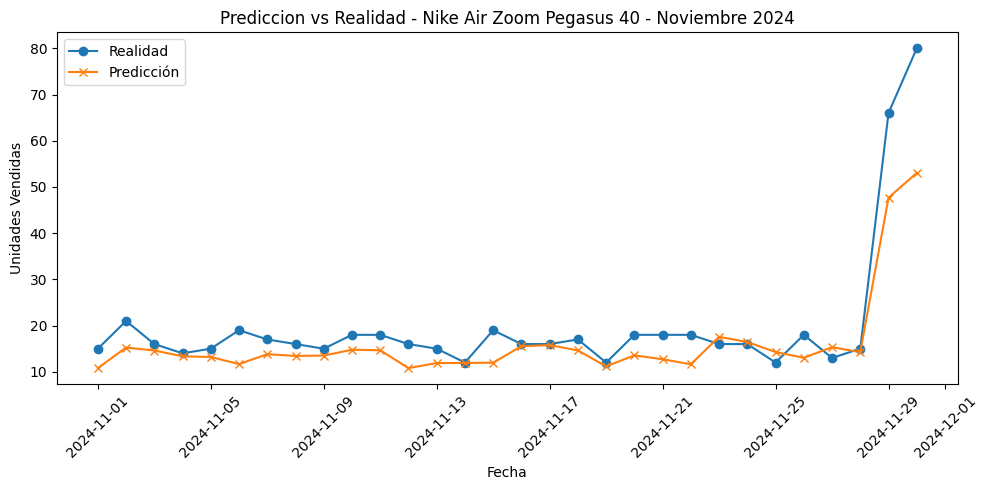

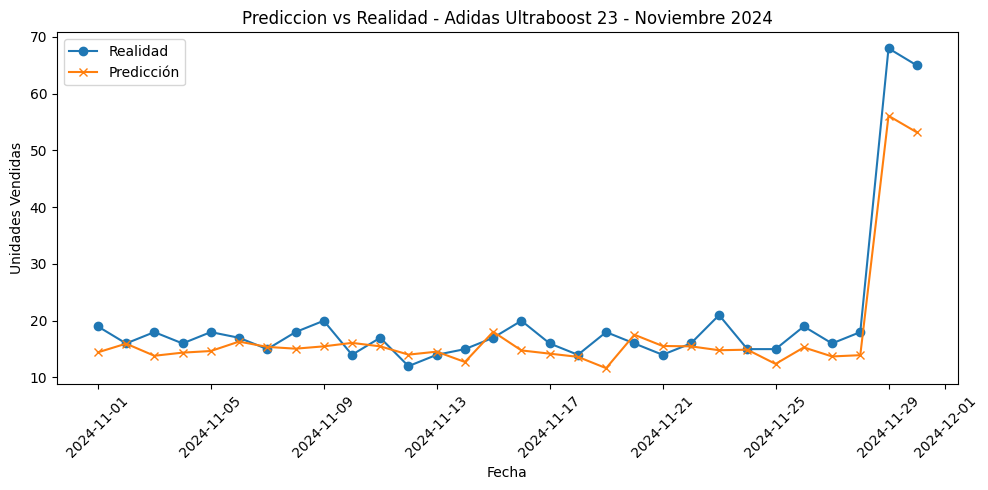

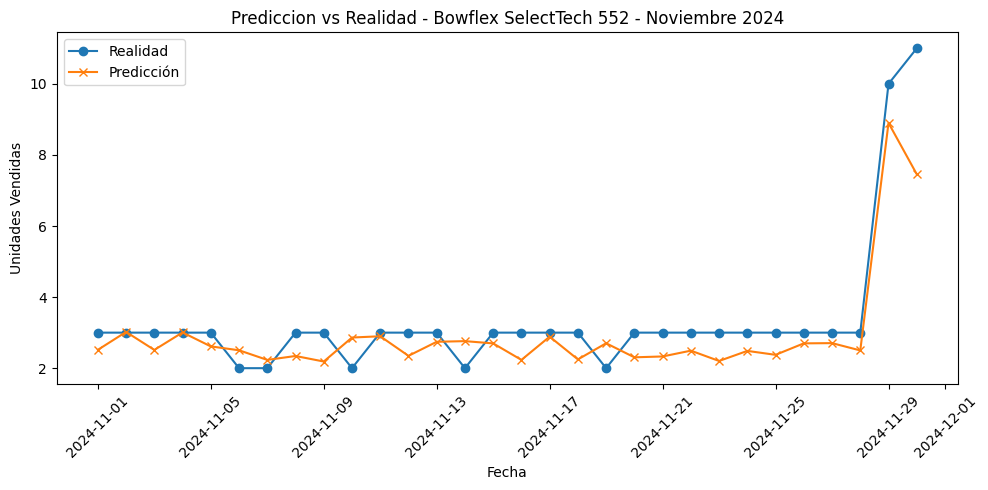

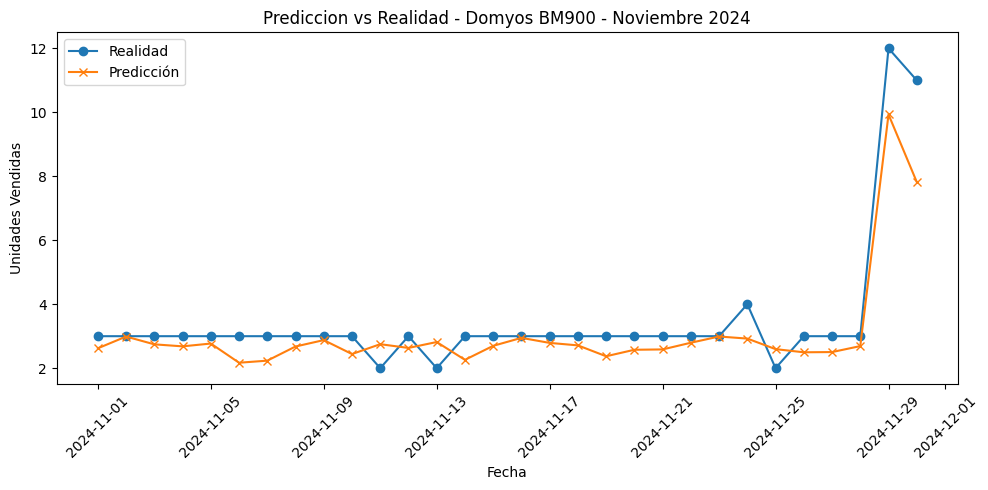

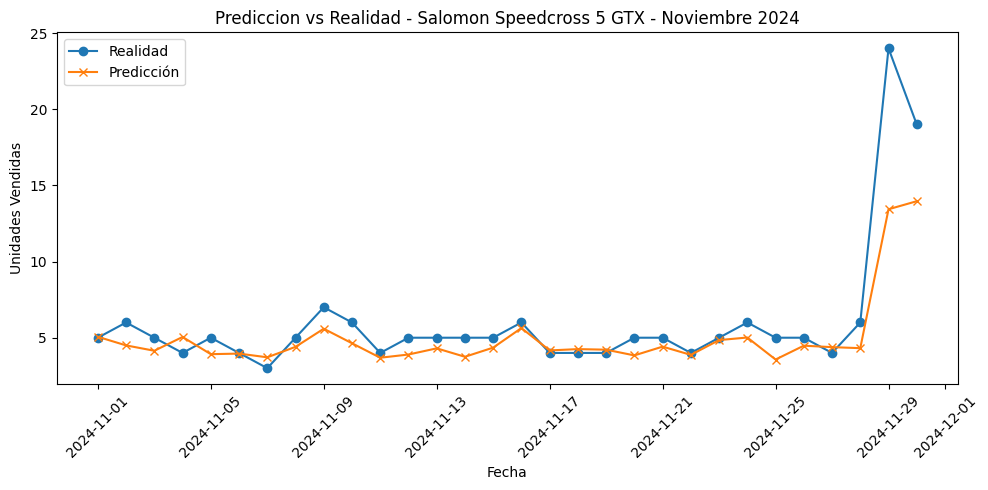

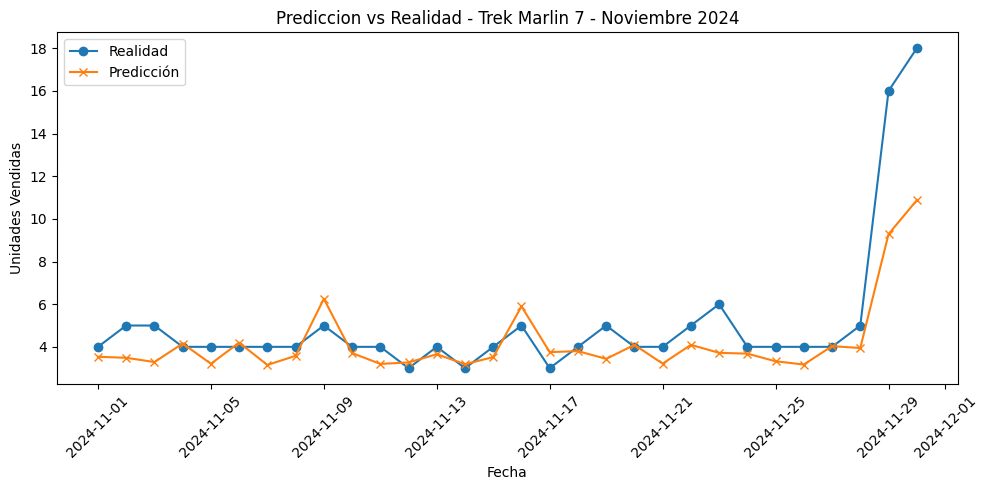

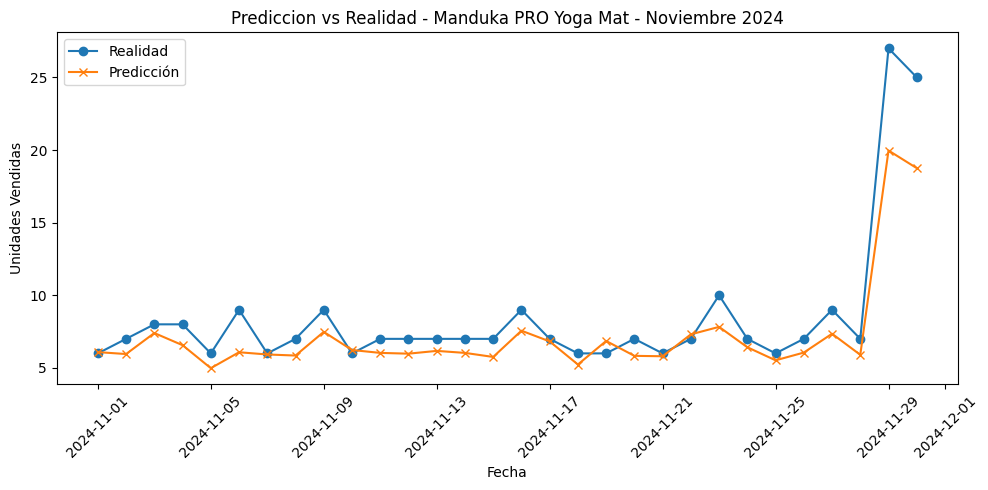

In [82]:
#Prediccion para noviembre 2024 de los siete productos estrella y visualizacion

#Filtramos para noviembre 2024 y productos estrella
noviembre_2024 = df[(df['año'] == 2024) & (df['mes'] == 11) & (df['es_estrella'] == 1)].copy()
productos_estrella = noviembre_2024['producto_id'].unique()

for producto_id in productos_estrella:
    df_prod = noviembre_2024[noviembre_2024['producto_id'] == producto_id].copy()
    nombre_prod = df_prod['nombre'].iloc[0]
    #Seleccionamos variables predictoras igual que en el modelo
    excluir =['fecha','ingresos','unidades_vendidas','nombre','producto_id','categoria','subcategoria']
    X_prod= df_prod.drop(columns=[col for col in excluir if col in df_prod.columns]+[col for col in df_prod.columns if df_prod[col].dtype == 'object'])
    y_real = df_prod['unidades_vendidas']
    #Prediccin
    y_pred_prod = model.predict(X_prod)
    #Grafico
    plt.figure(figsize=(10,5))
    plt.plot(df_prod['fecha'],y_real,label='Realidad',marker='o')
    plt.plot(df_prod['fecha'],y_pred_prod,label='Predicción',marker='x')
    plt.title(f'Prediccion vs Realidad - {nombre_prod} - Noviembre 2024')
    plt.xlabel('Fecha')
    plt.ylabel('Unidades Vendidas')
    plt.legend()
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

In [84]:
mae_productos = []

for producto_id in productos_estrella:

    df_prod = noviembre_2024[noviembre_2024['producto_id'] == producto_id].copy()
    nombre_prod = df_prod['nombre'].iloc[0]

    excluir = ['fecha','ingresos','unidades_vendidas','nombre','producto_id','categoria','subcategoria']

    X_prod = df_prod.drop(
        columns=[col for col in excluir if col in df_prod.columns] +
        [col for col in df_prod.columns if df_prod[col].dtype == 'object']
    )

    y_real = df_prod['unidades_vendidas']
    y_pred_prod = model.predict(X_prod)

    mae_prod = mean_absolute_error(y_real, y_pred_prod)

    mae_productos.append({
        'producto_id': producto_id,
        'nombre': nombre_prod,
        'mae': mae_prod
    })

print('MAE por producto estrella en noviembre 2024')

for prod in mae_productos:
    print(f"{prod['nombre']} (ID: {prod['producto_id']}): MAE = {prod['mae']:.2f}")

MAE por producto estrella en noviembre 2024
Nike Air Zoom Pegasus 40 (ID: PROD_001): MAE = 4.27
Adidas Ultraboost 23 (ID: PROD_002): MAE = 3.06
Bowflex SelectTech 552 (ID: PROD_009): MAE = 0.61
Domyos BM900 (ID: PROD_010): MAE = 0.57
Salomon Speedcross 5 GTX (ID: PROD_015): MAE = 1.21
Trek Marlin 7 (ID: PROD_016): MAE = 1.13
Manduka PRO Yoga Mat (ID: PROD_021): MAE = 1.34


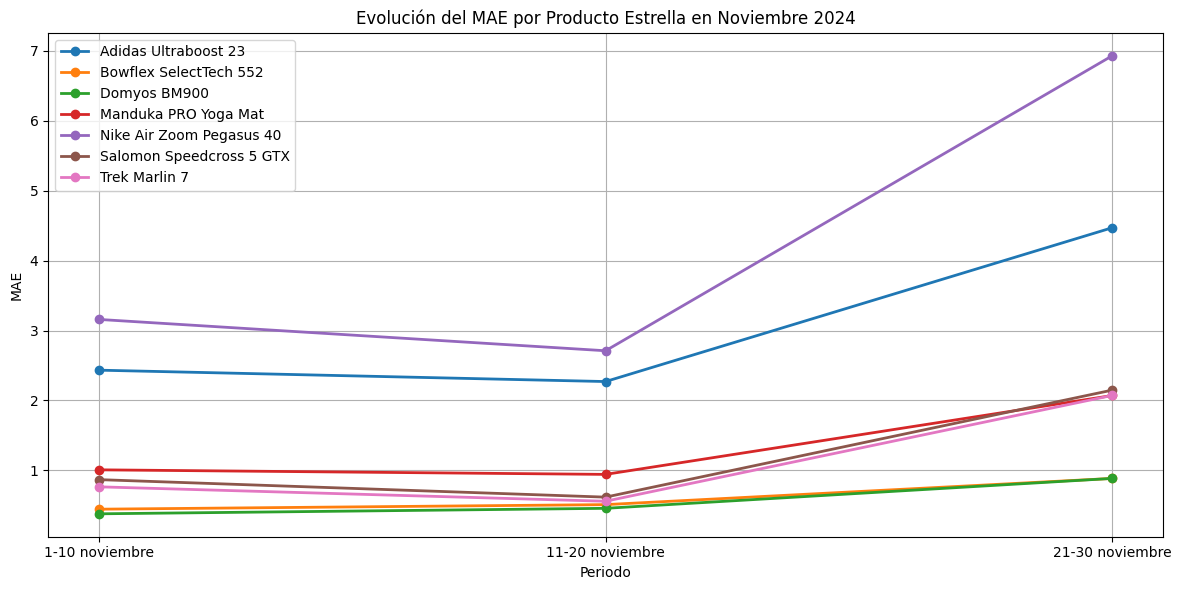

MAE por producto estrella y periodo en noviembre 2024


,producto_id,nombre,periodo,mae
3,PROD_002,Adidas Ultraboost 23,1-10 noviembre,2.433220
4,PROD_002,Adidas Ultraboost 23,11-20 noviembre,2.270453
5,PROD_002,Adidas Ultraboost 23,21-30 noviembre,4.470173
6,PROD_009,Bowflex SelectTech 552,1-10 noviembre,0.445191
7,PROD_009,Bowflex SelectTech 552,11-20 noviembre,0.510623
8,PROD_009,Bowflex SelectTech 552,21-30 noviembre,0.885250
9,PROD_010,Domyos BM900,1-10 noviembre,0.379089
10,PROD_010,Domyos BM900,11-20 noviembre,0.457661
11,PROD_010,Domyos BM900,21-30 noviembre,0.885463
18,PROD_021,Manduka PRO Yoga Mat,1-10 noviembre,1.008211


In [86]:
# Analisis de la degradacion del error en noviembre 2024 por periodos de 10 dias para productos estrella

# definir los 3 periodos
periodos = [(1,10),(11,20),(21,30)]

resultados = []

for producto_id in productos_estrella:

    df_prod = noviembre_2024[noviembre_2024['producto_id'] == producto_id].copy()
    nombre_prod = df_prod['nombre'].iloc[0]

    for inicio, fin in periodos:

        df_periodo = df_prod[(df_prod['dia_mes'] >= inicio) & (df_prod['dia_mes'] <= fin)].copy()

        if len(df_periodo) == 0:
            continue

        excluir = ['fecha','ingresos','unidades_vendidas','nombre','producto_id','categoria','subcategoria']

        X_periodo = df_periodo.drop(
            columns=[col for col in excluir if col in df_periodo.columns] +
            [col for col in df_periodo.columns if df_periodo[col].dtype == 'object']
        )

        y_real = df_periodo['unidades_vendidas']
        y_pred = model.predict(X_periodo)

        mae_periodo = mean_absolute_error(y_real, y_pred)

        resultados.append({
            'producto_id': producto_id,
            'nombre': nombre_prod,
            'periodo': f'{inicio}-{fin} noviembre',
            'mae': mae_periodo
        })

# convertir resultados a dataframe
resultados_df = pd.DataFrame(resultados)

# ordenar periodos
orden_periodos = ['1-10 noviembre','11-20 noviembre','21-30 noviembre']

resultados_df['periodo'] = pd.Categorical(
    resultados_df['periodo'],
    categories=orden_periodos,
    ordered=True
)

resultados_df = resultados_df.sort_values(['nombre','periodo'])

#  GRAFICO 

plt.figure(figsize=(12,6))

for producto in resultados_df['nombre'].unique():

    df_plot = resultados_df[resultados_df['nombre'] == producto]

    plt.plot(
        df_plot['periodo'],
        df_plot['mae'],
        marker='o',
        linewidth=2,
        label=producto
    )

plt.title('Evolución del MAE por Producto Estrella en Noviembre 2024')
plt.xlabel('Periodo')
plt.ylabel('MAE')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# TABLA RESULTADOS 

print('MAE por producto estrella y periodo en noviembre 2024')
display(resultados_df)

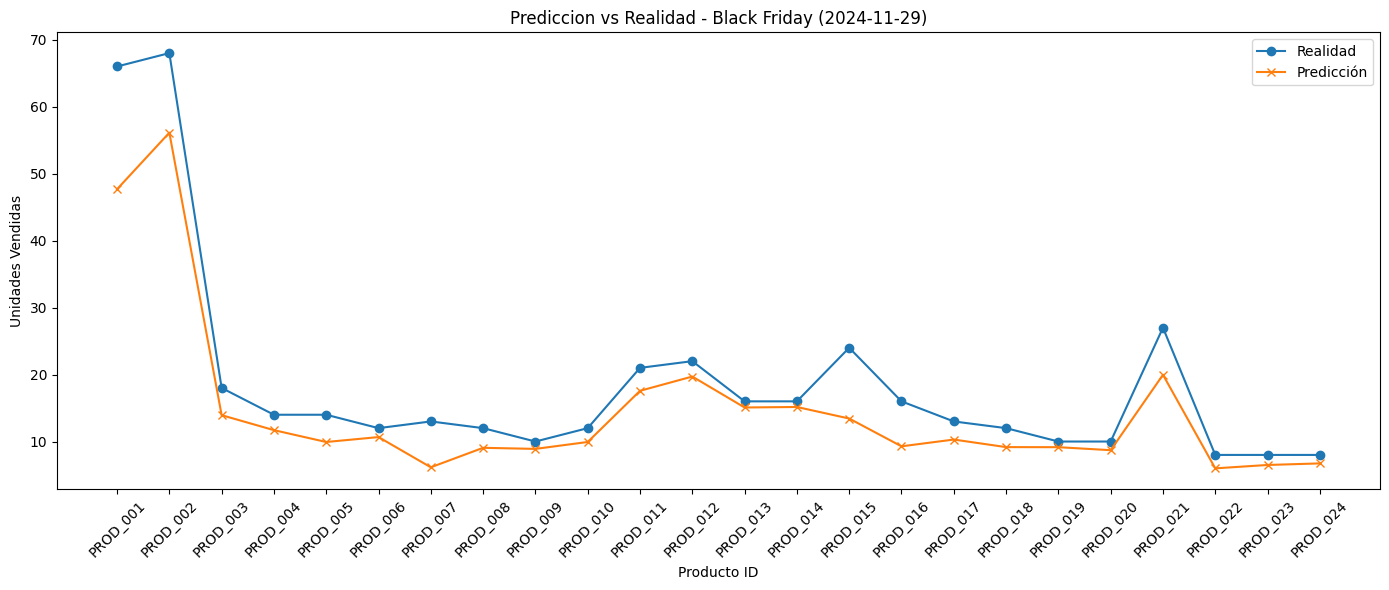

In [88]:
#Analisis especifico de Black Friday para todos los productos
black_friday_fecha = df[(df['año']==2024)& (df['es_black_friday'])]['fecha'].unique()
if len(black_friday_fecha) >0:
    fecha_bf = black_friday_fecha[0]
    df_bf = df[df['fecha'] == fecha_bf].copy()
    #Seleccionar variables predictoras igual que en el modelo
    excluir = ['fecha','ingresos','unidades_vendidas','nombre','producto_id','categoria','subcategoria']
    X_bf = df_bf.drop(columns=[col for col in excluir if col in df_bf.columns]+[col for col in df_bf.columns if df_bf[col].dtype == 'object'])
    y_real_bf = df_bf['unidades_vendidas']
    y_pred_bf = model.predict(X_bf)
    producto_ids = df_bf['producto_id'].values
    #Grafico
    plt.figure(figsize=(14,6))
    plt.plot(producto_ids, y_real_bf, label='Realidad', marker='o')
    plt.plot(producto_ids,y_pred_bf,label='Predicción',marker='x')
    plt.title(f'Prediccion vs Realidad - Black Friday ({fecha_bf.date()})')
    plt.xlabel('Producto ID')
    plt.ylabel('Unidades Vendidas')
    plt.legend()
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()
else:
    print("No se encontró la fecha de Black Friday en los datos.")

In [91]:
#Seleccion de variables predictoras (excluyendo fecha, ingresos, y tipo object)

excluir = ['fecha','ingresos','unidades_vendidas','nombre','producto_id','categoria','subcategoria']
X_full = df.drop(columns=[col for col in excluir if col in df.columns]+[col for col in df.columns if df[col].dtype == 'object'])
y_full = df['unidades_vendidas']


#Entrenamos el modelo
model_final = HistGradientBoostingRegressor(
    learning_rate=0.05,
    max_iter=400,
    max_depth=7,
    l2_regularization=1.0,
    random_state=42
)
model_final.fit(X_full, y_full)

print('Modelo final entrenado con todos los datos disponibles (2021-2024)')


Modelo final entrenado con todos los datos disponibles (2021-2024)


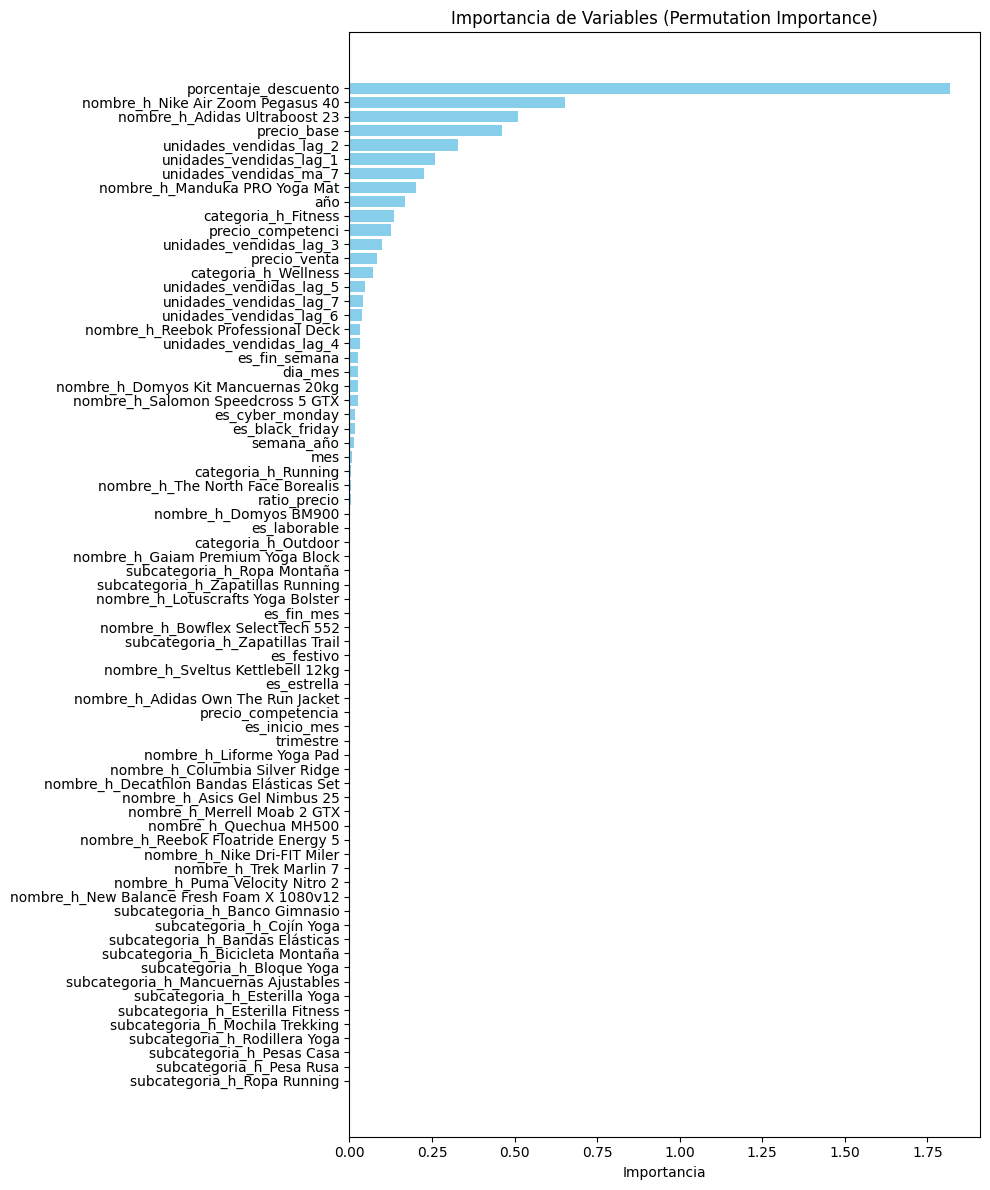

Modelo final guardado en '../models/model_final.joblib'


In [93]:
#importancia de variables con permutacion y guardado del modelo final
import joblib
from sklearn.inspection import permutation_importance
#Calcular permutation importance
result = permutation_importance(model_final, X_full, y_full, n_repeats=10, random_state=42, scoring='neg_mean_absolute_error')
importancias = result.importances_mean
features = X_full.columns

#Creamos dataframe de importancia y ordenar
importancia_df = pd.DataFrame({'feature': features, 'importance': importancias})
importancia_df = importancia_df.sort_values('importance', ascending=False)

#grafico de barras horizontales
plt.figure(figsize=(10,12))
plt.barh(importancia_df['feature'], importancia_df['importance'], color='skyblue')
plt.gca().invert_yaxis()
plt.title('Importancia de Variables (Permutation Importance)')
plt.xlabel('Importancia')
plt.tight_layout()
plt.show()

#Guardamos el modelo
joblib.dump(model_final, '../models/model_final.joblib')
print("Modelo final guardado en '../models/model_final.joblib'")
